# 03. Baseline: логистическая регрессия

В этом ноутбуке:
- загрузка обработанных данных
- обучение базовой модели логистической регрессии
- оценка качества на валидационной выборке
- подбор порога классификации по F1-мере
- подбор гиперпараметра C (регуляризация) с помощью GridSearchCV
- сравнение результатов и выбор финальной модели
- сохранение модели, метрик и графиков

### 1. Загрузка данных

In [28]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
import os

# Создаём папку для графиков этой модели
FIGURES_DIR = '../reports/figures/03_baseline_lr'
os.makedirs(FIGURES_DIR, exist_ok=True)

# Загрузка обработанных данных
X_train = np.load('../data/processed/X_train_scaled.npy')
X_val = np.load('../data/processed/X_val_scaled.npy')
y_train = np.load('../data/processed/y_train.npy')
y_val = np.load('../data/processed/y_val.npy')

print(f"Размер обучающей выборки: {X_train.shape[0]} строк")
print(f"Размер валидационной выборки: {X_val.shape[0]} строк")
print(f"Доля дефолтов в обучающей выборке: {y_train.mean():.4f}")
print(f"Доля дефолтов в валидационной выборке: {y_val.mean():.4f}")

Размер обучающей выборки: 119773 строк
Размер валидационной выборки: 29944 строк
Доля дефолтов в обучающей выборке: 0.0660
Доля дефолтов в валидационной выборке: 0.0660


### 2. Обучение базовой модели (C=1, class_weight='balanced')

In [29]:
lr_base = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_base.fit(X_train, y_train)
print("Базовая модель обучена")

Базовая модель обучена


### 3. Оценка качества на валидационной выборке

Precision: 0.2564
Recall:    0.6194
F1-score:  0.3627
ROC-AUC:   0.8165


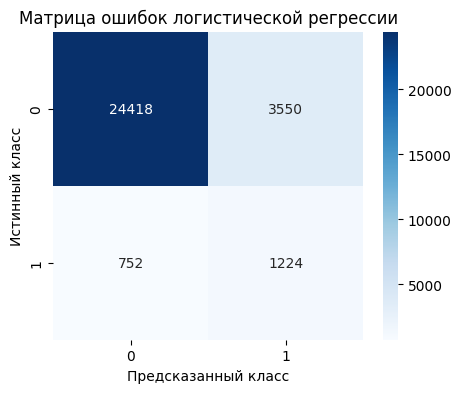

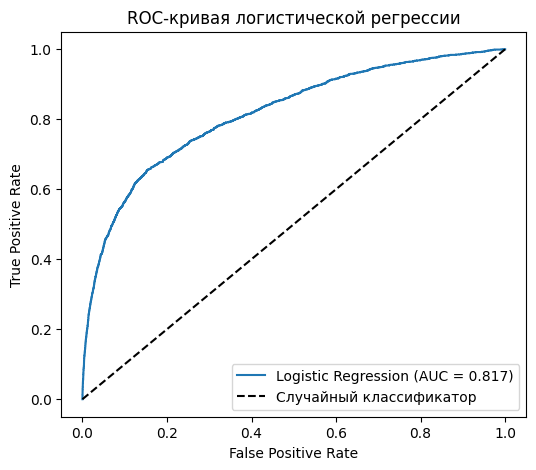

In [30]:
y_pred = lr_base.predict(X_val)
y_pred_proba = lr_base.predict_proba(X_val)[:, 1]

precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_pred_proba)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# Матрица ошибок
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок логистической регрессии')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.savefig(os.path.join(FIGURES_DIR, 'confusion_matrix.png'), bbox_inches='tight')
plt.show()

# ROC-кривая
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая логистической регрессии')
plt.legend()
plt.savefig(os.path.join(FIGURES_DIR, 'roc_curve.png'), bbox_inches='tight')
plt.show()

### 4. Подбор порога классификации по F1-мере

Лучший порог: 0.700
F1-score при этом пороге: 0.4109
После подбора порога (best=0.700):
Precision: 0.3766
Recall:    0.4519
F1-score:  0.4109


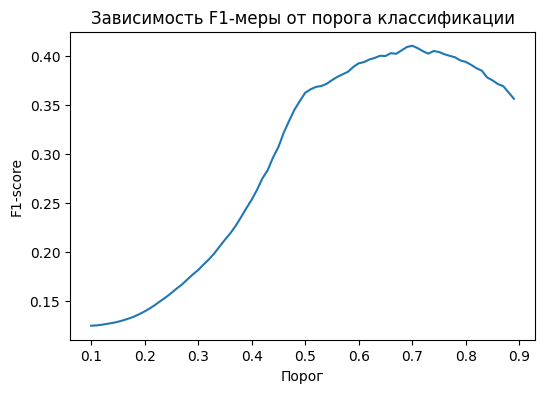

In [31]:
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_val, y_pred_proba >= t) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"Лучший порог: {best_threshold:.3f}")
print(f"F1-score при этом пороге: {best_f1:.4f}")

# Применяем новый порог
y_pred_adj = (y_pred_proba >= best_threshold).astype(int)
precision_adj = precision_score(y_val, y_pred_adj)
recall_adj = recall_score(y_val, y_pred_adj)
f1_adj = f1_score(y_val, y_pred_adj)

print(f"После подбора порога (best={best_threshold:.3f}):")
print(f"Precision: {precision_adj:.4f}")
print(f"Recall:    {recall_adj:.4f}")
print(f"F1-score:  {f1_adj:.4f}")

# График зависимости F1 от порога
plt.figure(figsize=(6,4))
plt.plot(thresholds, f1_scores)
plt.xlabel('Порог')
plt.ylabel('F1-score')
plt.title('Зависимость F1-меры от порога классификации')
plt.savefig(os.path.join(FIGURES_DIR, 'f1_vs_threshold.png'), bbox_inches='tight')
plt.show()

### 5. Подбор гиперпараметра C (регуляризация) с помощью GridSearchCV

In [32]:
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
lr_tune = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

grid = GridSearchCV(lr_tune, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Лучший C: {grid.best_params_['C']}")
print(f"Лучший ROC-AUC на кросс-валидации: {grid.best_score_:.4f}")

# Оценка модели с лучшим C на валидации
best_lr = grid.best_estimator_
y_pred_best = best_lr.predict(X_val)
y_pred_proba_best = best_lr.predict_proba(X_val)[:, 1]

precision_best = precision_score(y_val, y_pred_best)
recall_best = recall_score(y_val, y_pred_best)
f1_best = f1_score(y_val, y_pred_best)
roc_auc_best = roc_auc_score(y_val, y_pred_proba_best)

print(f"Метрики модели с C={grid.best_params_['C']}:")
print(f"Precision: {precision_best:.4f}")
print(f"Recall:    {recall_best:.4f}")
print(f"F1-score:  {f1_best:.4f}")
print(f"ROC-AUC:   {roc_auc_best:.4f}")

Лучший C: 100
Лучший ROC-AUC на кросс-валидации: 0.8186
Метрики модели с C=100:
Precision: 0.2562
Recall:    0.6189
F1-score:  0.3624
ROC-AUC:   0.8165


### 6. Вывод: лучшая модель не отличается от базовой → финальная модель = базовая

In [33]:
print("Сравнение базовой модели (C=1) и модели с оптимальным C:")
print(f"Базовая: Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, AUC={roc_auc:.4f}")
print(f"Оптимальная: Precision={precision_best:.4f}, Recall={recall_best:.4f}, F1={f1_best:.4f}, AUC={roc_auc_best:.4f}")
print("Метрики практически идентичны. Финальной моделью оставляем базовую (C=1).")

# Выбираем финальную модель
lr_final = lr_base

Сравнение базовой модели (C=1) и модели с оптимальным C:
Базовая: Precision=0.2564, Recall=0.6194, F1=0.3627, AUC=0.8165
Оптимальная: Precision=0.2562, Recall=0.6189, F1=0.3624, AUC=0.8165
Метрики практически идентичны. Финальной моделью оставляем базовую (C=1).


### 7. Сохранение модели, метрик и графиков

In [36]:
# Сохранение модели
model_dir = '../models'
os.makedirs(model_dir, exist_ok=True)
with open(os.path.join(model_dir, 'logistic_regression.pkl'), 'wb') as f:
    pickle.dump(lr_final, f)

# Сохранение метрик в текстовый файл
with open(os.path.join(FIGURES_DIR, 'metrics.txt'), 'w', encoding='utf-8') as f:
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall:    {recall:.4f}\n")
    f.write(f"F1-score:  {f1:.4f}\n")
    f.write(f"ROC-AUC:   {roc_auc:.4f}\n")
    f.write(f"\nЛучший порог (по F1): {best_threshold:.3f}\n")
    f.write(f"Precision при лучшем пороге: {precision_adj:.4f}\n")
    f.write(f"Recall при лучшем пороге:    {recall_adj:.4f}\n")
    f.write(f"F1 при лучшем пороге:        {f1_adj:.4f}\n")
    f.write(f"\nЛучший C (GridSearch): {grid.best_params_['C']}\n")
    f.write(f"Precision при лучшем C: {precision_best:.4f}\n")
    f.write(f"Recall при лучшем C:    {recall_best:.4f}\n")
    f.write(f"F1-score при лучшем C:  {f1_best:.4f}\n")
    f.write(f"ROC-AUC при лучшем C:   {roc_auc_best:.4f}\n")

print("Модель и метрики сохранены")

Модель и метрики сохранены
